In [1]:
import pandas as pd
import numpy as np 

INPUT = pd.read_csv("./dados/Input_2.csv")
OUTPUT = pd.read_excel("./dados/Saidas_2.xlsx")

INPUT = INPUT.ffill()
OUTPUT = OUTPUT.ffill()

display(INPUT)
display(OUTPUT)

PREDICTORS = ["Fi", "Fv"]
TARGETS = ["L", "T"]

,Fi,Fv
0,11.136722,16.949206
1,11.136722,16.949206
2,11.136722,16.949206
3,11.136722,16.949206
4,11.136722,16.949206
...,...,...
9995,18.223096,9.403950
9996,18.223096,9.403950
9997,18.223096,9.403950
9998,18.223096,9.403950


,L,T
0,2.165329,46.780751
1,2.257282,47.460484
2,2.325614,47.809683
3,2.376621,47.994379
4,2.414819,48.094087
...,...,...
9995,6.779368,42.777396
9996,6.779022,42.780006
9997,6.778730,42.781859
9998,6.778484,42.783175


In [2]:
# Selecionar apenas colunas desejadas
inputs = INPUT[PREDICTORS].reset_index(drop=True)
outputs = OUTPUT[TARGETS].reset_index(drop=True)

# Concatenar ignorando índices
data = pd.concat([inputs, outputs], axis=1)

import numpy as np

X = data[PREDICTORS].values.T   # (2 x N)
meanX = np.mean(X, axis=1)   # média por variável
stdX  = np.std(X, axis=1, ddof=0)  # desvio padrão (igual ao StandardScaler)

print("meanX:", meanX)
print("stdX:", stdX)

Y = data[TARGETS].values.T   # (2 x N)
meanY = np.mean(Y, axis=1)   # média por variável
stdY  = np.std(Y, axis=1, ddof=0)  # desvio padrão (igual ao StandardScaler)

print("meanY:", meanY)
print("stdY:", stdY)

meanX: [11.54549372 12.4514907 ]
stdX: [4.23449211 3.9104502 ]
meanY: [ 3.07519347 46.57397573]
stdY: [2.11485258 3.02168235]


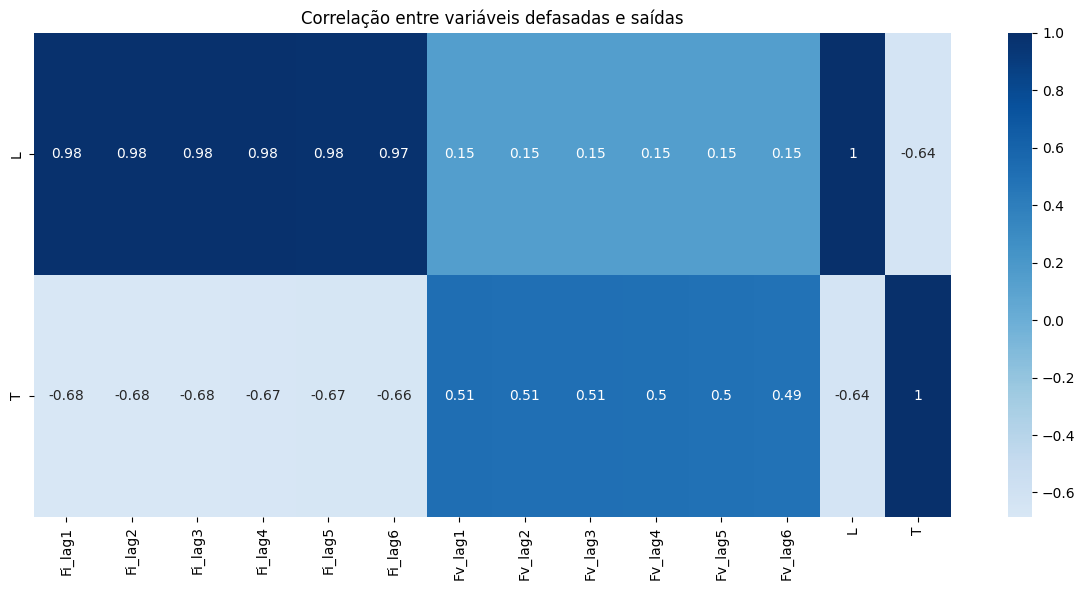

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================
# Análise de Lags
# ==============================

n_lags = 6

lagged_data = pd.DataFrame()

for col in PREDICTORS:
    for lag in range(1, n_lags + 1):
        lagged_data[f"{col}_lag{lag}"] = data[col].shift(lag)

# adicionar targets
for t in TARGETS:
    lagged_data[t] = data[t]

# remover NaN
lagged_data = lagged_data.dropna()


# ==============================
# Correlação
# ==============================

corr = lagged_data.corr()

plt.figure(figsize=(12,6))

sns.heatmap(
    corr[TARGETS].T,
    annot=True,
    cmap="Blues",
    center=0
)

plt.title("Correlação entre variáveis defasadas e saídas")

plt.tight_layout()

plt.show()

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np

TIME_STEPS = 1

def CreateSequences(input_data, target_data, timesteps):
    X_seq, Y_seq = [], []
    
    for i in range(timesteps, len(input_data)):
        X_seq.append(input_data.iloc[i-timesteps:i].values)
        Y_seq.append(target_data.iloc[i])
    return np.array(X_seq), np.array(Y_seq)

# Scale our data to have mean 0
SCALER = StandardScaler()
OUT_SCALER = StandardScaler()

data[PREDICTORS] = SCALER.fit_transform(data[PREDICTORS])
data[TARGETS] = OUT_SCALER.fit_transform(data[TARGETS])

# Split into train (70%), validation (15%), and test (15%) sets
train_data, temp_data = train_test_split(data, test_size=0.3, shuffle=False)
valid_data, test_data = train_test_split(temp_data, test_size=0.5, shuffle=False)

In [5]:
# Criar sequências temporais
train_x, train_y = CreateSequences(train_data[PREDICTORS], train_data[TARGETS], TIME_STEPS)
x_val, y_val = CreateSequences(valid_data[PREDICTORS], valid_data[TARGETS], TIME_STEPS)
x_test, y_test = CreateSequences(test_data[PREDICTORS], test_data[TARGETS], TIME_STEPS)

print("Train:", train_x.shape, train_y.shape)
print("Val:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (6999, 1, 2) (6999, 2)
Val: (1499, 1, 2) (1499, 2)
Test: (1499, 1, 2) (1499, 2)


In [6]:
import matplotlib.pyplot as plt
import keras

def compile_model(model, epochs=500, patience=20):

    # Compilando o modelo
    model.compile(loss="mse", optimizer="adam")

    # Early stopping
    early_stop = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=patience,
        restore_best_weights=True,
        verbose=1
    )

    # Treinando o modelo
    history = model.fit(
        train_x,
        train_y,
        epochs=epochs,
        validation_data=(x_val, y_val),
        callbacks=[early_stop],
        verbose=False
    )

    # Avaliando o modelo
    mse_v = model.evaluate(x_val, y_val, verbose=0)
    print(f"Validation MSE: {mse_v:.4f}")
    
    mse_t = model.evaluate(x_test, y_test, verbose=0)
    print(f"Teste MSE: {mse_t:.4f}")

    # Plot do histórico
    plt.figure(figsize=(8,5))
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.title("Training History")
    plt.legend()
    plt.grid(True)
    plt.show()

    return history

In [7]:
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

def nrmse(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse / (np.max(y_true) - np.min(y_true))


def eval_model(model):

    datasets = {
        "Train": (train_x, train_y),
        "Validation": (x_val, y_val),
        "Test": (x_test, y_test)
    }

    for name, (x, y) in datasets.items():

        print("\n" + "="*50)
        print(f"{name} DATASET")
        print("="*50)
        
        
        pred = model.predict(x)

        for i, target in enumerate(TARGETS):

            y_true = y[:, i]
            y_pred = pred[:, i]

            r2 = r2_score(y_true, y_pred)
            error = nrmse(y_true, y_pred)

            print(f"\nTarget: {target}")
            print(f"R2    : {r2:.4f}")
            print(f"NRMSE : {error:.4f}")

In [8]:

def plot_model_results(model):

    datasets = [
        ("Train", train_x, train_y),
        ("Validation", x_val, y_val),
        ("Test", x_test, y_test)
    ]

    fig, axes = plt.subplots(3, 2, figsize=(14,10))
    axes = axes.flatten()

    plot_id = 0

    for name, x, y in datasets:

        pred = model.predict(x)

        for t, target in enumerate(TARGETS):

            ax = axes[plot_id]

            ax.plot(y[:, t], label="Real", linewidth=2)
            ax.plot(pred[:, t], linestyle="--", label="Pred", linewidth=2)

            ax.set_title(f"{name} - {target}")
            ax.set_xlabel("Sample")
            ax.set_ylabel(target)
            ax.grid(True)

            if plot_id == 0:
                ax.legend()

            plot_id += 1

    plt.tight_layout()
    plt.show()

In [9]:
INPUT_SIZE = len(PREDICTORS)
OUTPUT_SIZE = len(TARGETS)

complex_dense_RNN = keras.models.Sequential([
    keras.layers.Input(shape=(TIME_STEPS, INPUT_SIZE)),
    keras.layers.SimpleRNN(64, return_sequences=True),
    keras.layers.SimpleRNN(32),
    keras.layers.Dense(OUTPUT_SIZE)
])

Epoch 96: early stopping
Restoring model weights from the end of the best epoch: 76.
Validation MSE: 0.0125
Teste MSE: 0.0210


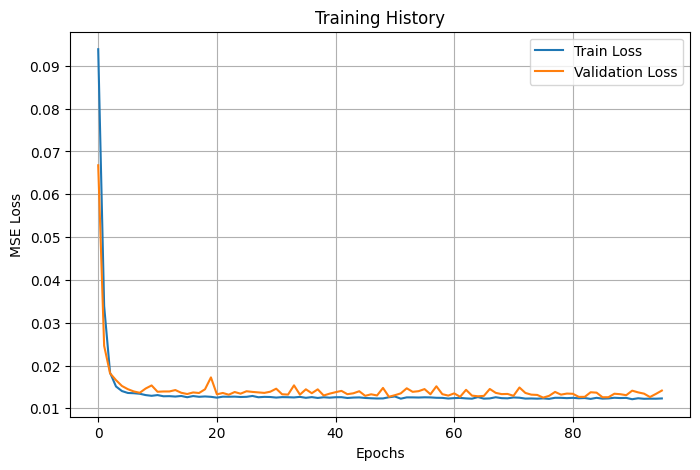

In [10]:
compile_model(complex_dense_RNN)

In [11]:
eval_model(complex_dense_RNN)


Train DATASET


219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Target: L
R2    : 0.9845
NRMSE : 0.0315

Target: T
R2    : 0.9888
NRMSE : 0.0192

Validation DATASET
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Target: L
R2    : 0.9855
NRMSE : 0.0374

Target: T
R2    : 0.9913
NRMSE : 0.0197

Test DATASET
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Target: L
R2    : 0.9616
NRMSE : 0.0523

Target: T
R2    : 0.9897
NRMSE : 0.0227


219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


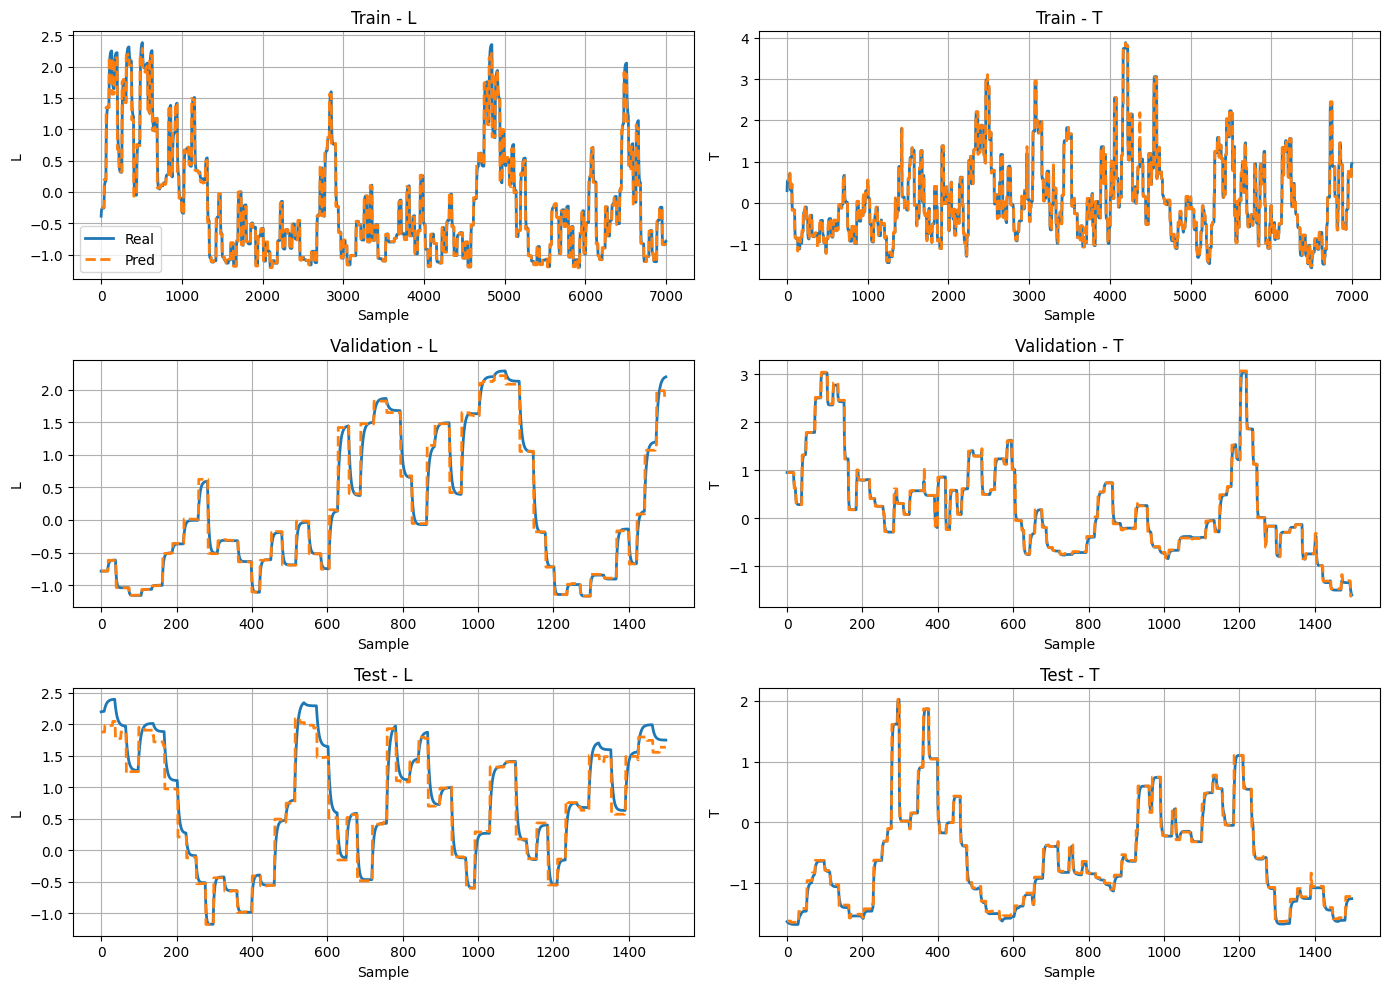

In [12]:
plot_model_results(complex_dense_RNN)

# Exportando Modelo

In [ ]:
# Modelo 1 Time_Step
complex_dense_RNN.save('model_JT.h5', include_optimizer=False)

# Modelo N Time_Steps
# complex_dense_RNN.save('model_JacketedTank.h5', include_optimizer=False)

print(complex_dense_RNN.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 1, 64)          │         4,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,376 (87.41 KB)

 Trainable params: 7,458 (29.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 14,918 (58.28 KB)

None


In [ ]:
import tensorflow as tf
import tf2onnx

# 1. Carregar modelo
#model = tf.keras.models.load_model("model_JacketedTank.h5", compile=False)
model = tf.keras.models.load_model("model_JT.h5", compile=False)

# 2. Recriar modelo funcional (ESSENCIAL)
inputs = tf.keras.Input(shape=(TIME_STEPS, INPUT_SIZE))
outputs = model(inputs)

model_fixed = tf.keras.Model(inputs=inputs, outputs=outputs)

# 3. Converter
spec = (tf.TensorSpec((None, TIME_STEPS, INPUT_SIZE), tf.float32),)

onnx_model, _ = tf2onnx.convert.from_keras(
    model_fixed,
    input_signature=spec,
    opset=13
)
# 4. Salvar
# with open("model_JacketedTank.onnx", "wb") as f:
with open("model_JT.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())

In [15]:
import numpy as np

# salvar pesos
pesos = complex_dense_RNN.get_weights()

for i, w in enumerate(pesos):
    np.savetxt(f"Pesos/peso_{i}.csv", w, delimiter=",")

# complex_dense_RNN.summary()

In [16]:
for layer in complex_dense_RNN.layers:
    print(f"\nCamada: {layer.name}")
    weights = layer.get_weights()
    
    for i, w in enumerate(weights):
        print(f"  Peso {i}: shape = {w.shape}")


Camada: simple_rnn
  Peso 0: shape = (2, 64)
  Peso 1: shape = (64, 64)
  Peso 2: shape = (64,)

Camada: simple_rnn_1
  Peso 0: shape = (64, 32)
  Peso 1: shape = (32, 32)
  Peso 2: shape = (32,)

Camada: dense
  Peso 0: shape = (32, 2)
  Peso 1: shape = (2,)


# Teste Degrau

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


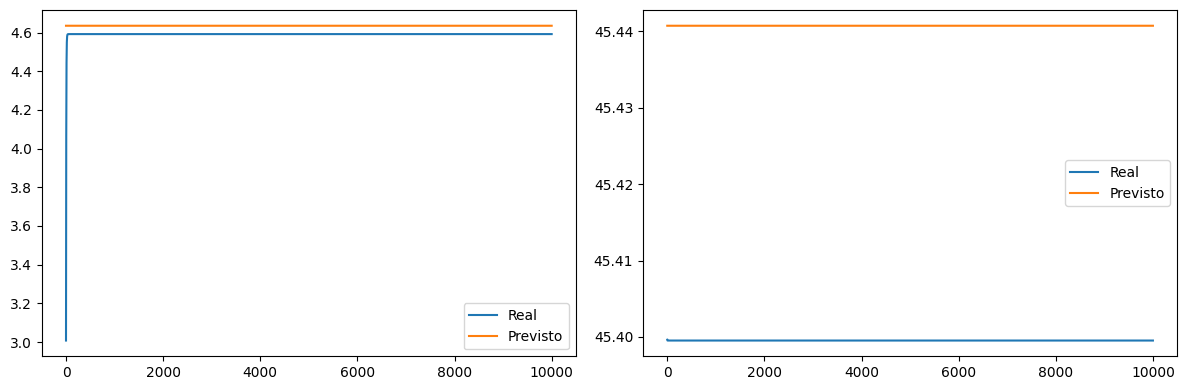


Erro: [[-54.1060785   -0.09058704]
 [-39.20977698  -0.09069296]
 [-29.41606975  -0.09074738]
 ...
 [ -0.94086689  -0.09082123]
 [ -0.94086689  -0.09082123]
 [ -0.94086689  -0.09082123]]


In [17]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
#Teste Do Modelo

INPUT_test = pd.read_csv("./dados/Input_Teste.csv")
OUTPUT_test = pd.read_excel("./dados/Saidas_Teste_xlsx.xlsx")

INPUT_test = INPUT_test.ffill()
OUTPUT_test = OUTPUT_test.ffill()

#display(INPUT_test)
#display(OUTPUT_test)

PREDICTORS_test = ["Fi", "Fv"]
TARGETS_test = ["L", "T"]

# Normalizar entrada
INPUT_test[PREDICTORS_test] = SCALER.transform(INPUT_test[PREDICTORS_test])

# Normalizar saída (para comparação)
OUTPUT_test[TARGETS_test] = OUT_SCALER.transform(OUTPUT_test[TARGETS_test])

X_suave, Y_suave = CreateSequences(INPUT_test[PREDICTORS_test], OUTPUT_test[TARGETS_test], TIME_STEPS)

Y_pred = complex_dense_RNN.predict(X_suave)

Y_pred = OUT_SCALER.inverse_transform(Y_pred)
Y_suave  = OUT_SCALER.inverse_transform(Y_suave)

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, axs = plt.subplots(1, 2, figsize=(12,4))

axs[0].plot(Y_suave[:,0], label='Real')
axs[0].plot(Y_pred[:,0], label='Previsto')
axs[0].legend()

axs[1].plot(Y_suave[:,1], label='Real')
axs[1].plot(Y_pred[:,1], label='Previsto')
axs[1].legend()

# remover notação científica
formatter = ScalarFormatter()
formatter.set_scientific(False)

axs[0].yaxis.set_major_formatter(formatter)
axs[1].yaxis.set_major_formatter(formatter)

plt.tight_layout()
plt.show()
print(f'\nErro:', (Y_suave-Y_pred)*100/Y_suave)
# print(f'Saida Real:', Y_suave, '\nSaida Prevista:', Y_pred, '\nErro:', (Y_suave-Y_pred)*100/Y_suave)

# Teste de Normalização

In [23]:
import numpy as np

# Normalização
meanX = np.array([11.54549372, 12.4514907])
stdX = np.array([4.23449211, 3.9104502])
meanY = np.array([ 3.07519347, 46.57397573])
stdY = np.array([2.11485258, 3.02168235])
def std(x):
    return (x - meanX) / stdX
def destd(y_norm):
    return (y_norm * stdY) + meanY

C:\Users\allan\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


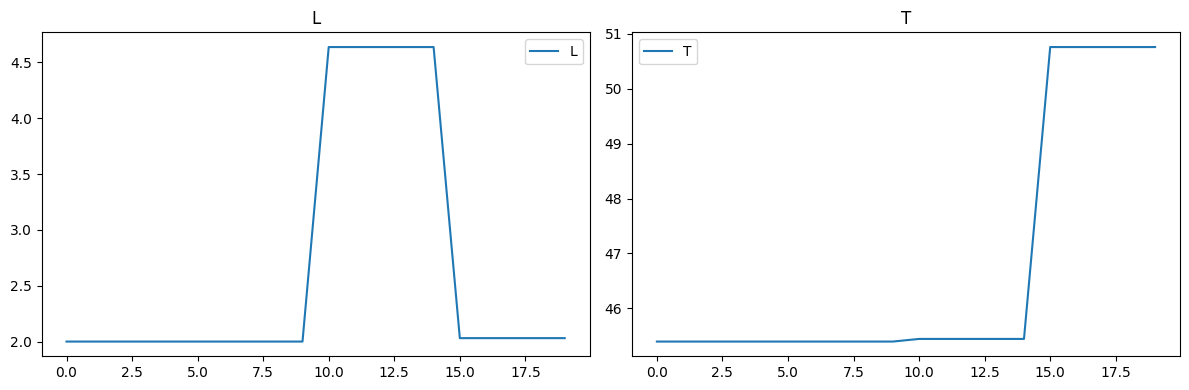

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# carregar modelo
model = load_model("model_JT.h5", compile=False)

# tempo de simulação
N = 20

# entrada: [Fi, Fv]
u = np.zeros((N, 2))

# degrau em Fi
u[:, 0] = 10.0   # valor inicial
u[10:, 0] = 15.0 # degrau no tempo 20
u[15:, 0] = 10.0 # degrau no tempo 20

# manter Fv constante
u[:, 1] = 10.0
u[10:, 1] = 15.0 # degrau no tempo 20
u[15:, 1] = 20.0 # degrau no tempo 20
# normalizar entrada
u_norm = SCALER.transform(u)
#u_norm = std(u)

# armazenar saída
y_pred = np.zeros((N, 2))

# histórico inicial (TIME_STEPS = 1)
x_input = np.zeros((1, 1, 2))  # (batch, time_steps, features)

for k in range(N):

    # entrada atual
    x_input[0, 0, :] = u_norm[k]

    # predição
    yk = model.predict(x_input, verbose=0)

    # salvar
    y_pred[k] = yk[0]

# desnormalizar saída
y_pred_real = OUT_SCALER.inverse_transform(y_pred)
#y_pred_real = destd(y_pred)

# ------------ PLOT ----------------
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(y_pred_real[:,0], label="L")
plt.title("L")
plt.legend()

plt.subplot(1,2,2)
plt.plot(y_pred_real[:,1], label="T")
plt.title("T")
plt.legend()

plt.tight_layout()
plt.show()